# POWERLIFT PREDICTOR
### Predict the score for any one of the following three lifts, based on the other two:
- Squat
- Bench Press
- Deadlift

This Data Science analysis is performed on a [Powerlifting Dataset](https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database) (pre-filtered for memory usage purposes), to perform Data preprocessing, Data cleaning, Feature Engineering, Exploratory Data Analysis (EDA), Data Visualization, Predictive Modeling, Model Evaluation, and Deployment

In [204]:
# IMPORTING LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

In [205]:
# LOADING DATASET

FILE_PATH = "./powerlifting-dataset.csv"

pldf_raw = pd.read_csv(FILE_PATH, index_col=0)

print("DATASET LOADED")
pldf_raw.shape

DATASET LOADED


(3043013, 6)

The raw dataset will remain unaltered and simply cloned into a new "working" dataframe 

## DATA COLLECTION AND PREPARATION

In [206]:
# COPYING RAW DATASET INTO WORKING DATAFRAME

df = pldf_raw.copy()

df.head()

,Sex,Age,BodyweightKg,Best3SquatKg,Best3BenchKg,Best3DeadliftKg
0,F,33.0,58.30,80.0,60.0,107.5
1,F,43.0,73.10,105.0,67.5,110.0
2,M,15.5,67.40,100.0,62.5,105.0
3,M,35.0,66.65,137.5,122.5,170.0
4,M,26.5,72.45,90.0,50.0,125.0


Formatting the columns allows for easy reading and handling

In [207]:
# RENAMING AND FORMAT COLUMNS

df.rename(
    columns = {
        "BodyweightKg": "WEIGHT",
        "Best3SquatKg": "SQUAT",
        "Best3BenchKg": "BENCH",
        "Best3DeadliftKg": "DEADLIFT"
    },
    inplace = True
)
df.rename(columns = lambda col: col.upper(), inplace=True)
df.head(5)

,SEX,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT
0,F,33.0,58.30,80.0,60.0,107.5
1,F,43.0,73.10,105.0,67.5,110.0
2,M,15.5,67.40,100.0,62.5,105.0
3,M,35.0,66.65,137.5,122.5,170.0
4,M,26.5,72.45,90.0,50.0,125.0


After formatting the columns, each feature will be examined individually, starting with the descriptions (distrbutions, counts, values, etc)

In [208]:
# CHECKING "SEX" VALUES AND COUNTS

print(df["SEX"].value_counts(dropna=False))

SEX
M     2290122
F      752828
Mx         63
Name: count, dtype: int64


The "SEX" value "Mx" does not correspond to either Male or Female. Its purpose is unclear.
This issue can be approached by:
- Imputing "Mx" values -- using KNN or alternative
- Omitting the rows: losing 63 values (from over 3 million)
- Omitted the SEX column: losing an entire attribute due to a few unusual values

In [209]:
# FEATURE ENGINEERING "SEX" ATTRIBUTE AS BINARY VARIABLE (dropping "Mx" values)
df = df[~(df["SEX"] == "Mx")]
df["SEX"].describe()

count     3042950
unique          2
top             M
freq      2290122
Name: SEX, dtype: object

The 63 rows containing "SEX" values of "Mx" have been omitted. Such a small quantity of samples should not strongly impact insights in the data, and even if they did, they would be considered outliers anyway. Even though it's possible to extract information of biological sex from the names of the contestants, there is much guess-work involved. Therefore, for ethical and mathematical concerns, the dataset has been filtered down to only males and females.

In [210]:
# FEATURE ENGINEERING "SEX" ATTRIBUTE TO BINARY VARIABLE

df["IS_MALE"] = pd.get_dummies(df["SEX"], drop_first=True).astype(int)
df.drop(columns=["SEX"], inplace=True)
df.head(5)

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
0,33.0,58.30,80.0,60.0,107.5,0
1,43.0,73.10,105.0,67.5,110.0,0
2,15.5,67.40,100.0,62.5,105.0,1
3,35.0,66.65,137.5,122.5,170.0,1
4,26.5,72.45,90.0,50.0,125.0,1


In [211]:
# CHECKING "AGE" VALUES AND COUNTS

n_null_age = df[pd.isna(df["AGE"])].shape[0]
pct_null_age = np.round(n_null_age/df.shape[0]*100, 2)

print("Amount of missing AGE values:")
print(f"{n_null_age} of {df.shape[0]} ({pct_null_age}%)")
print('\n')

age_description = df["AGE"].describe().round().astype(int)
print(age_description)

Amount of missing AGE values:
1070333 of 3042950 (35.17%)


count    1972617
mean          31
std           13
min            0
25%           20
50%           28
75%           38
max           98
Name: AGE, dtype: int64


The AGE column seems to have values of 0. 
Similar to the issue with the SEX column, this issue has a few possible approaches:
- Impute the invalid values
- Omit the rows
- Omit the entire AGE column

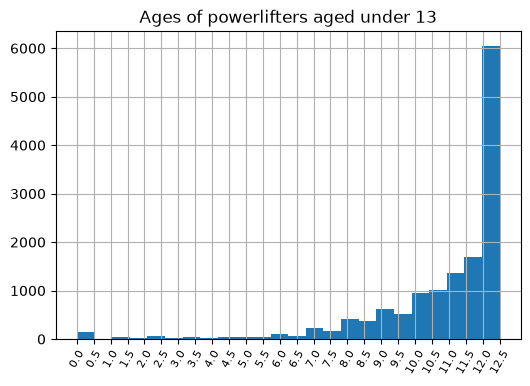

In [212]:
# PLOTTING UNDERAGE POWERLIFTERS' AGES (DISTRIBUTION)

young_kids = df[df["AGE"] < 13]

plt.figure()
plt.xticks([x/2 for x in range(0, 26, 1)])
plt.title("Ages of powerlifters aged under 13")

young_kids["AGE"].hist(
    xlabelsize=8,
    xrot=60,
    figsize=(6, 4),
    bins=24     # bins set to double that of total, to capture half-year increment (ex: 11.5)
)
plt.show()

There are also alarmingly low values in this column, even as low as 0.5!
This has to be a data entry error.
Nearly 14 thousand rows are from children under 13.
For ethical purposes, these may need to be omitted entirely.

Further investigation is due to determine how much of these are errors in data entry.
There is a notable increase in count from x=10 onwards, so ages below that level must be prioritized for data cleaning.

There is a sharp increase as ages approach 13. Domain research (from Google) shows 8 years is the minimum age for a child to join the "Youth Division" of some powerlifting competition, while other sources show a minimum age of 13. Since no sources show acceptance of contestants aged under 8 years, samples with AGE values under 8 will be removed (first).

In [213]:
# REMOVING CONTESTANTS YOUNGER THAN 8 YEARS OLD

df = df[~(df["AGE"] < 8)]
df["AGE"].describe().round()

count    1971583.0
mean          31.0
std           13.0
min            8.0
25%           20.0
50%           28.0
75%           38.0
max           98.0
Name: AGE, dtype: float64

Almost 1000 samples have been removed, since their AGE was too low. This also includes incorrectly entered values, such as 0.5. This threshold may need to be moved higher.

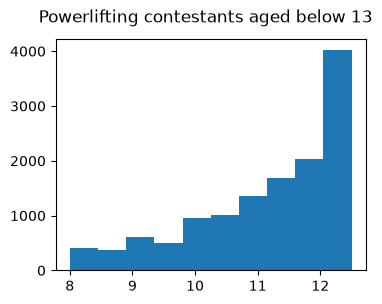

In [214]:
# RE-EXAMINING AND RE-DEFINING YOUNG CHILDREN (SUBSET) CONTESTANTS

young_kids = df.loc[df["AGE"] < 13]

plt.figure(figsize=(4, 3))
plt.suptitle("Powerlifting contestants aged below 13")
plt.hist(young_kids["AGE"])
plt.show()

Observation: Age 10 marks a threshold. Not only is there a notable increase from age 10 onwards, but samples below age 10 are very low in number, and also the distribution has local minimums. However, from age 10 onwards, there are no local minimums and there is continuous increase with age.

In [215]:
# CHECKING "WEIGHT" VALUES AND 5-NUMBER SUMMARY

df["WEIGHT"].describe().round(2)

count    3003578.00
mean          84.18
std           22.62
min           10.00
25%           67.20
50%           81.95
75%           98.80
max          300.00
Name: WEIGHT, dtype: float64

The WEIGHT column seems to contain some values which are alarmingly low and alarmingly high.
The validity of these values must be confirmed via further analysis.

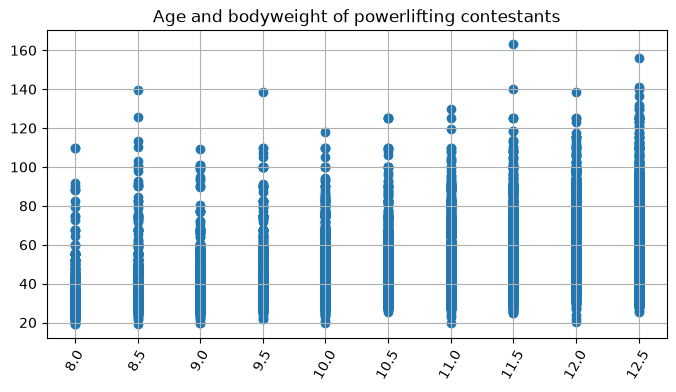

In [216]:
# COMPARING BODYWEIGHTS OF CONTESTANTS OF DIFFERENT AGES

plt.figure(figsize = (8, 4))
plt.xticks(
    ticks = [x/2 for x in range(0, 26, 1)],
    rotation = 60
)
plt.title("Age and bodyweight of powerlifting contestants")
plt.scatter(x=young_kids["AGE"], y=young_kids["WEIGHT"])
plt.grid(True)
plt.show()

Not only are extremely low AGE values guaranteed to be faulty entries, but many individuals have unrealistic WEIGHT values for their age (ex: a 6-year-old weighing 170kg, AKA ~374 lbs).
These values need to be handled by imputation or omission.

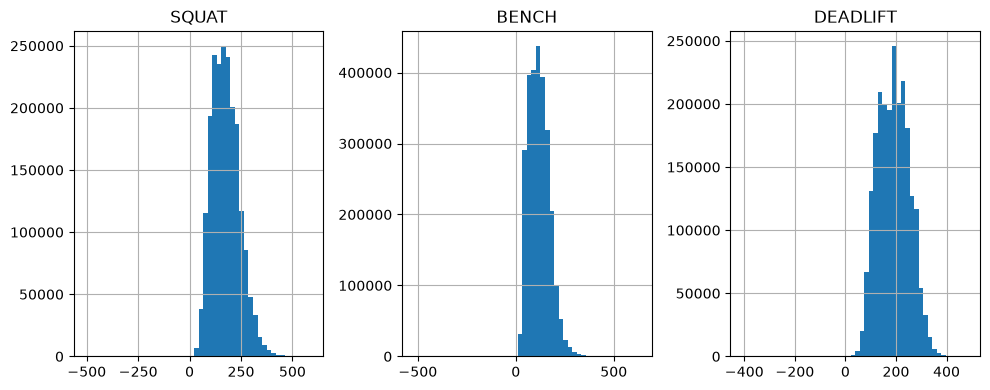

,SQUAT,BENCH,DEADLIFT
count,2033263.00,2683568.00,2205409.00
mean,174.47,118.14,190.13
std,68.36,53.56,62.01
min,-508.02,-522.50,-410.00
25%,122.50,75.00,142.50
50%,170.00,115.00,190.00
75%,217.72,151.95,235.00
max,595.00,635.50,487.50


In [217]:
# ANALYZING AND PLOTTING LIFT SCORES

lifts = ["SQUAT", "BENCH", "DEADLIFT"]

fig, axes = plt.subplots(ncols=len(lifts), figsize=(10, 4))

for lift,ax in zip(lifts, axes):
    ax.hist(df[lift], bins=50)
    ax.set_title(lift)
    ax.grid(True)

plt.tight_layout()
plt.show()

df[lifts].describe().round(2)

The presence of lift scores below zero indicates one or more of the followinga:
- errors in data entry
- scoring convention (failed attempts are recorded as negative)

This formatting system is leading to data science issues which can be fixed with either:
- replacing the invalid scores via imputation
- omitting the rows containing the invalid scores

In [218]:
# EXAMINING NEGATIVE VALUES

def get_invalid_scores(df):
    invalid_lifts = pd.DataFrame()

    for lift in lifts:
        invalid_lifts.loc[lift.capitalize(), "n_negatives"] = df[df[lift] < 0].shape[0]
        invalid_lifts.loc[lift.capitalize(), "n_nulls"] = df[np.isnan(df[lift])].shape[0]
        

    invalid_lifts = invalid_lifts.astype(int)

    invalid_lifts.loc["Total"] = invalid_lifts.sum()
    invalid_lifts["Total"] = invalid_lifts.sum(axis=1)

    print(f"Invalid lift scores: ({(invalid_lifts.loc["Total", "Total"]/df.shape[0] * 100).round(2)}%)")
    return invalid_lifts

get_invalid_scores(df)

Invalid lift scores: (72.68%)


,n_negatives,n_nulls,Total
Squat,3022,1008653,1011675
Bench,3125,358348,361473
Deadlift,1187,836507,837694
Total,7334,2203508,2210842


Over 2.2 million samples contain invalid scores, which is over 72% of the entire dataset. This is a big problem.
Omitting all these values would be losing lots of valuable data, so imputation may be necessary.
Let's start with fixing the negative values. 

Over 7000 samples have at least one negative score. These can be turned into nulls and then imputed.
However, imputation becomes less practical for a given sample if that sample also has multiple invalid scores.
A small amount of samples may even have invalid scores for all three lifts. Those must be removed, without a doubt.

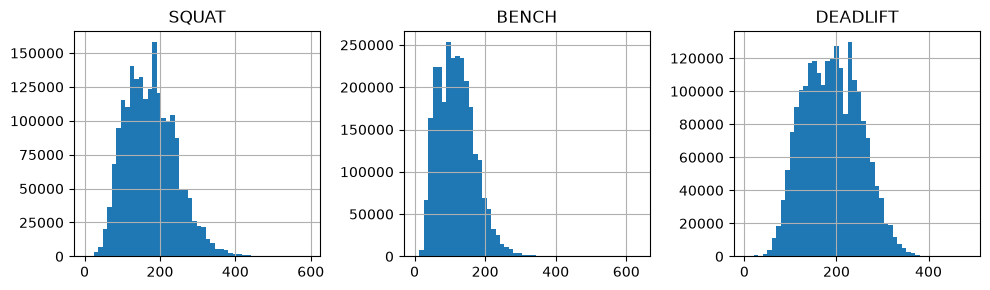

,SQUAT,BENCH,DEADLIFT
count,2030241.00,2680443.00,2204222.00
mean,175.02,118.46,190.35
std,66.81,52.69,61.27
min,1.00,1.00,1.00
25%,124.74,75.00,142.50
50%,170.00,115.00,190.00
75%,217.72,151.95,235.00
max,595.00,635.50,487.50


In [219]:
# TURNING ALL NEGATIVE SCORES INTO NULLS

fig, axes = plt.subplots(ncols = len(lifts), figsize=(10, 3))
for lift, ax in zip(lifts, axes):
    neg_val_idx = df.loc[df[lift] < 0, lift].index
    df.loc[neg_val_idx, lift] = None

    ax.set_title(lift)
    ax.grid(True)
    ax.hist(df[lift], bins=50)

plt.tight_layout()
plt.show()
df[lifts].describe().round(2)

There are no more negative values, as confirmed by the descriptions of the scores, although they have minimums of only 1, which is likely to be from error in data entry. The histogram distributions have a standard unimodal shape, indicating that the data is becoming more properly formatted. However, there are still many NULL values to handle, along with the newly converted ones. That will be the next step.

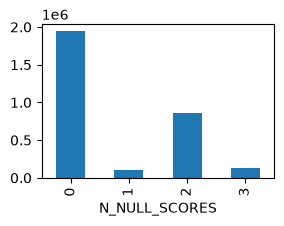

N_NULL_SCORES
0    1944547
2     863485
3     124994
1     108890
Name: count, dtype: int64


Before removing unscored: 3041916 total samples
After removing unscored: 2916922 total samples


In [220]:
# REMOVING ROWS MISSING SCORES FOR ALL THREE LIFTS

df["N_NULL_SCORES"] = np.zeros(df.shape[0]).astype(int)

for lift in lifts:
    df.loc[np.isnan(df[lift]), "N_NULL_SCORES"] += 1

plt.figure()
df["N_NULL_SCORES"].value_counts().sort_index().plot(kind="bar", figsize=(3, 2))
plt.show()
print(df["N_NULL_SCORES"].value_counts())

print('\n')

print(f"Before removing unscored: {df.shape[0]} total samples")
df = df[df["N_NULL_SCORES"] != 3]
print(f"After removing unscored: {df.shape[0]} total samples")

Over 100k samples can be imputed since they are only missing 1 score, but a slightly higher number of other samples MUST be removed since they have no recorded scores at all. 
Even more surprising is that a significantly larger chunk of samples are missing exactly TWO values. Luckily, though, the vast majority of the dataset has score values for all lifts.

In [221]:
# CHECKING AMOUNT OF INVALID SCORES AGAIN

get_invalid_scores(df)

Invalid lift scores: (62.94%)


,n_negatives,n_nulls,Total
Squat,0,886681,886681
Bench,0,236479,236479
Deadlift,0,712700,712700
Total,0,1835860,1835860


The amount of invalid scores has reduced from 2.2 million to 1.8 million. That's roughly 400k samples corrected, which is good progress. Total total percentage is also down from 72% to 62%, a difference of 10% so far, despite the fact that the dataset has shrunk in size. Still, a lot of cleaning remains to be done. The next step is to examine the rows with exactly two missing values, since those comprise a large amount.

In [222]:
# CHECKING NUMBER OF MISSING SCORES PER LIFT, AMONG SAMPLES MISSING EXACTLY TWO SCORES

missing_2_lifts = df[df["N_NULL_SCORES"] == 2]
print(f"{missing_2_lifts.shape[0]} of {df.shape[0]}  samples missing exactly 2 lifts")
print(str(np.round(missing_2_lifts.shape[0] / df.shape[0] * 100)) + "%")

for lift in lifts:
    print(f"Missing {lift}:", missing_2_lifts[lift].isnull().sum())

863485 of 2916922  samples missing exactly 2 lifts
30.0%
Missing SQUAT: 816020
Missing BENCH: 222154
Missing DEADLIFT: 688796


Among rows missing exactly TWO values, bench press has the least amount of missing scores, and squat has the highest amount of missing scores, with deadlift being a close second to squat.
In other words, there is a high number of contestants who only performed a bench press and did not perform squats or deadlifts (as per the dataset).

In [223]:
# CHECKING COMBINATIONS OF MISSING LIFTS AMONG SAMPLES MISSING EXACTLY TWO SCORES

for lift in lifts:    
    print(f"Only has {lift}: {missing_2_lifts[~np.isnan(missing_2_lifts[lift])].shape[0]}")

Only has SQUAT: 47465
Only has BENCH: 641331
Only has DEADLIFT: 174689


Hypothesis confirmed: 
- ~641k samples only have BENCH and missing SQUAT and DEADLIFT
- ~174k samples only have DEADLIFT and missing SQUAT and BENCH
- ~47k samples only have SQUAT and missing BENCH and DEADLIFT

Although 30% of the entire dataset is a large chunk, it's still better to remove these incomplete samples due to the fact that they simply do not contain enough information for reliable imputation. The potential inaccuracy that would be introduced by trying to impute TWO missing scores from the remaining attributes (some of which can still have NULL values too) would only misinform the predictive model. Also, the dataset is large enough to lose 30% of its data and still be very populated still. Therefore, samples missing 2 scores will be removed.

In [224]:
# REMOVING SAMPLES MISSING 2 SCORES
df.drop(missing_2_lifts.index, inplace=True)
df.shape

(2053437, 7)

Over 2 million samples remain in the dataset, which is still a substantial number of rows to extract valuable insights and train a predictive model. Further analysis of other attributes will likely result in more omission going forward.

In [225]:
# FEATURE ENGINEERING SCORE-PERCENTAGES OF TOTAL (TWO NEW FEATURES)

df["TOTAL"] = df[lifts].sum(axis=1)

for lift in lifts:
    df[f"{lift}_PCT"] = df[lift]/df["TOTAL"] * 100

df.head()

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE,N_NULL_SCORES,TOTAL,SQUAT_PCT,BENCH_PCT,DEADLIFT_PCT
0,33.0,58.30,80.0,60.0,107.5,0,0,247.5,32.323232,24.242424,43.434343
1,43.0,73.10,105.0,67.5,110.0,0,0,282.5,37.168142,23.893805,38.938053
2,15.5,67.40,100.0,62.5,105.0,1,0,267.5,37.383178,23.364486,39.252336
3,35.0,66.65,137.5,122.5,170.0,1,0,430.0,31.976744,28.488372,39.534884
4,26.5,72.45,90.0,50.0,125.0,1,0,265.0,33.962264,18.867925,47.169811


Plotted using 1944547 samples


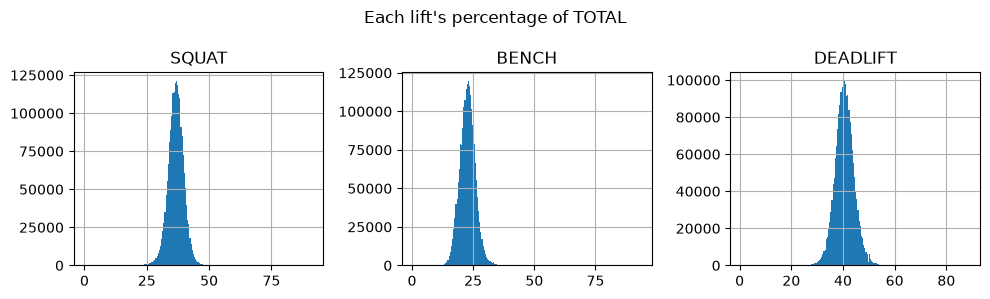

In [226]:
# PLOTTING EACH LIFT'S PERCENTAGE DISTRIBUTION

fig, axes = plt.subplots(ncols=3, figsize=(10, 3))
fig.suptitle("Each lift's percentage of TOTAL")

samples_without_nulls = df[df["N_NULL_SCORES"] == 0]

for lift, ax in zip(lifts, axes):
    ax.hist(
        samples_without_nulls[f"{lift}_PCT"],
        bins=200
    )

    ax.set_title(f"{lift}")
    ax.grid(True)
plt.tight_layout()
print(f"Plotted using {samples_without_nulls.shape[0]} samples")
plt.show()

The distribution of each lift's percentage (from total) seem normal without any alarming outliers or bimodality. Therefore it's safe to conclude that there aren't large amounts of contestants who have disproportionate records of strength. To work around NULL values, the data has been filtered to only use samples containing scores for all three lifts. The PCT columns will be dropped from the dataframe from this point.

In [227]:
# REMOVING LIFT PERCENTAGE SCORES SINCE THEY ARE NOT UNUSUAL

df.drop(columns=[f"{lift}_PCT" for lift in lifts], inplace=True)

df

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE,N_NULL_SCORES,TOTAL
0,33.0,58.30,80.0,60.0,107.5,0,0,247.5
1,43.0,73.10,105.0,67.5,110.0,0,0,282.5
2,15.5,67.40,100.0,62.5,105.0,1,0,267.5
3,35.0,66.65,137.5,122.5,170.0,1,0,430.0
4,26.5,72.45,90.0,50.0,125.0,1,0,265.0
...,...,...,...,...,...,...,...,...
3043008,45.0,109.30,242.5,187.5,215.0,0,0,645.0
3043009,27.5,113.22,237.5,195.0,200.0,0,0,632.5
3043010,37.5,110.79,227.5,200.0,190.0,0,0,617.5
3043011,39.5,124.53,220.0,150.0,145.0,0,0,515.0


In [228]:
# ANALYZING SAMPLES MISSING ONLY 1 SCORE

missing_1_lift = df[df["N_NULL_SCORES"] == 1]
print(f"{missing_1_lift.shape[0]} samples missing only 1 score")
missing_1_lift.head(5)

108890 samples missing only 1 score


,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE,N_NULL_SCORES,TOTAL
14,29.5,90.85,180.0,NaN,180.0,1,1,360.0
15,32.0,104.65,220.0,NaN,240.0,1,1,460.0
16,43.5,99.80,160.0,NaN,200.0,1,1,360.0
17,31.5,86.45,NaN,120.0,180.0,1,1,300.0
18,47.0,89.10,NaN,90.0,130.0,1,1,220.0


Since over 100k samples are missing only one score, these are prime candidates for imputation. As an extra measure, it's also important to make sure they aren't missing other important attributes either (age, sex, weight, etc), so this will be further filtered to exclude NULL values in those other features.

In [229]:
# FEATURE ENGINEERING ATTRIBUTE FOR MISSING NULL VALUES PER SAMPLE

df["N_NULL_FEATURES"] = np.zeros(df.shape[0]).astype(int)

for dependent_feature in df.columns:
    df.loc[df[dependent_feature].isnull(), "N_NULL_FEATURES"] += 1

df[df["N_NULL_FEATURES"] >= 1].head(5)

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE,N_NULL_SCORES,TOTAL,N_NULL_FEATURES
14,29.5,90.85,180.0,NaN,180.0,1,1,360.0,1
15,32.0,104.65,220.0,NaN,240.0,1,1,460.0,1
16,43.5,99.80,160.0,NaN,200.0,1,1,360.0,1
17,31.5,86.45,NaN,120.0,180.0,1,1,300.0,1
18,47.0,89.10,NaN,90.0,130.0,1,1,220.0,1


Now it's time to find samples with 2 or more NULL values, be it for scores, age, weight, etc.

In [230]:
# CHECKING FOR SAMPLES MISSING 2 OR MORE VALUES

print(df[df["N_NULL_FEATURES"] > 1].shape[0], end= " ")
print("rows missing 2 or more values")

49397 rows missing 2 or more values


~50k rows is relatively a small fraction of the entire dataset, so the better option is to remove these samples, since imputing them would introduce more potential flaws in the data and misinform the model, leading to improper (or outright failed) generalization.

In [231]:
# REMOVING SAMPLES MISSING 2 OR MORE VALUES
df = df[df["N_NULL_FEATURES"] <= 1]
df.shape

(2004040, 9)

The dataset still retains just over 2 million samples, more than enough to extract valuable insights and train a model.

Now it's time to examine the amount of NULL values per feature.

In [232]:
# EXAMINING AMOUNT OF NULL VALUES PER FEATURE

df.isnull().sum().sort_values(ascending=False)

AGE                781194
SQUAT               48911
DEADLIFT            10586
BENCH                9530
WEIGHT               3868
IS_MALE                 0
N_NULL_SCORES           0
TOTAL                   0
N_NULL_FEATURES         0
dtype: int64

We see that "AGE" has, by far, the most missing values. Among the lifts, "SQUAT" has the most missing values. There is also no overlap between these missing values, so each sample missing a certain value is ONLY missing that particular value.

Omitting all these values would be the fastest way to leave a dataset with only complete rows. Even though the approach is simplistic, it would still leave the dataset with over 1 million samples, which is still a very large amount. Furthermore, imputing the missing values would also introduce potentially faulty data to an already uncertain dataset. Therefore, the rows containing missing values will be omitted, leaving behind still well over a million rows to work with.

In [233]:
# REMOVING SAMPLES CONTAINING NULL VALUES, NULL-TRACKER COLUMNS, AND "TOTAL" FEATURE (REDUNDANT)

df.drop(df[df["N_NULL_FEATURES"] > 0].index, inplace=True)

df.drop(columns=["N_NULL_SCORES", "N_NULL_FEATURES", "TOTAL"], inplace=True)

print(f"{df.shape[0]} complete rows in dataset")
print(f"{df.isnull().sum().sum()} missing values remaining")

1149951 complete rows in dataset
0 missing values remaining


## EXPLORATORY DATA ANALYSIS

In [234]:
# DEFINING NUMERICAL AND BINARY FEATURES

binary_features = ["IS_MALE"]
numerical_features = [feature for feature in df.columns if feature not in binary_features]

In [235]:
# PAIRPLOT OF NUMERICAL FEATURES

# sns.pairplot(df[numerical_features])
# commented out for computational cost (image displayed in markdown below)

![Pairplot of numerical features](./img/num_features_pairplot.png)

The pairplot reveals a few outliers that need to be removed from the dataset, in order to preserve its generalizability. The goal is to preserve the shape of the "cluster" formed by the data points, and "unblur the edges" by removing the peripheral points.
- AGE: Does not have (m)any outliers present with any other feature. This is behaving as expected.
- WEIGHT: has outliers with all attributes. In each graph, at least one sample is extremely heavy, as well as an extremely light individual. Although it would be desirable to remove these samples, the model must be informed of the insight derived from this, which is that being heavier does help with strength, but only up to a certain point. In the extremely high weight classes, strength does not increase as rapidly.
- SQUAT: Does not have many notable outliers
- BENCH: Has at least one extremely strong outlier in each graph. This may be an error in data entry.
- DEADLIFT: Does not have many notable outliers

### Removing outliers

#### Attribute: WEIGHT

In [236]:
# GENERATING 5 NUMBER SUMMARIES FOR ALL NUMERICAL FEATURES
df[numerical_features].describe().round(2)

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT
count,1149951.00,1149951.00,1149951.00,1149951.00,1149951.00
mean,28.60,83.45,181.48,116.99,199.06
std,11.99,22.13,69.25,50.08,61.95
min,8.00,18.00,1.00,5.00,7.50
25%,19.50,66.90,127.50,75.00,150.00
50%,25.00,81.50,180.00,115.00,200.00
75%,34.50,97.50,227.50,150.00,245.00
max,95.50,285.00,595.00,544.31,487.50


In [237]:
# ANALYZING THE TOP 5 HEAVIEST CONTESTANTS

df.sort_values(by="WEIGHT", ascending=False)[:5]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
2134251,25.0,285.0,312.5,217.5,297.5,1
1840568,32.5,260.0,160.0,160.0,250.0,1
2112834,32.0,246.8,232.5,120.0,205.0,1
1081569,46.5,245.0,145.5,82.5,140.0,0
1708372,32.0,242.4,385.0,295.0,312.5,1


The heaviest contestants have scores that are not as high in quantile as their weight. 
Due to these odd proportions in values, these outliers will be removed.

In [238]:
# ANALYZING THE TOP 5 LIGHTEST CONTESTANTS

df.sort_values(by="WEIGHT", ascending=True)[:5]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
2403175,18.0,18.00,110.00,45.00,135.00,0
199716,8.5,19.00,37.50,30.00,52.50,1
324309,8.0,19.50,34.93,20.41,54.43,1
324394,8.0,19.96,38.56,22.68,54.43,1
324181,8.0,21.14,40.82,22.68,52.16,1


The lightest contestant is 18kg (~40 lbs) 18 years old. That is too grown and too strong for someone so light. This is definitely an outlier, and most likely a data entry error. Therefore, this sample will be removed.

#### IDENTIFYING PARTICULAR INDIVIDUAL SAMPLES

In [239]:
df[(df["WEIGHT"] > 240) & (df["AGE"] > 60)]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
1076839,68.0,241.8,207.5,162.5,170.0,1


In [240]:
df[(df["WEIGHT"] > 220) & (df["AGE"] > 50)]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
120821,58.0,226.7,220.0,115.0,230.0,1
1076839,68.0,241.8,207.5,162.5,170.0,1


In [241]:
df[(df["WEIGHT"] < 30) & (df["AGE"] > 20)]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
2296618,29.0,24.95,25.0,15.0,30.0,1


In [242]:
# REMOVING HEAVIEST CONTESTANT DUE TO IRREGULARLY DISPROPORTIONAL SCORES (TO WEIGHT)

df.drop(
    [
        2403175, # lightest

        2134251, # heaviest
        1840568,

        # other outliers
        1076839,
        120821
    ], 
    inplace=True
)

In [243]:
# ANALYZING HEAVIEST CONTESTANTS AFTER REMOVING OUTLIERS

df.sort_values(by="WEIGHT", ascending=False)[:5]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
2112834,32.0,246.8,232.5,120.0,205.0,1
1081569,46.5,245.0,145.5,82.5,140.0,0
1708372,32.0,242.4,385.0,295.0,312.5,1
1701240,40.0,242.0,242.5,182.5,200.0,1
1427199,21.0,242.0,227.5,185.0,242.5,1


In [244]:
# ANALYZING LIGHTEST CONTESTANTS AFTER REMOVING OUTLIERS

df.sort_values(by="WEIGHT", ascending=True)[:5]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
199716,8.5,19.00,37.50,30.00,52.50,1
324309,8.0,19.50,34.93,20.41,54.43,1
324394,8.0,19.96,38.56,22.68,54.43,1
324181,8.0,21.14,40.82,22.68,52.16,1
2023345,8.0,21.32,22.68,13.61,43.09,1


In [245]:
# DEFINING FUNCTION TO PLOT ANY FEATURE AGAINST ALL OTHERS

def scatterplot_array(dataframe, independent_feature, dependent_features):
    
    for dependent_feature in dependent_features:
        if dependent_feature == independent_feature:
            continue
        
        plt.figure()

        plt.scatter(
            x = dataframe[independent_feature], 
            y = dataframe[dependent_feature]
        )

        plt.xlabel(independent_feature)
        plt.ylabel(dependent_feature)

        independent_feature_max = dataframe[independent_feature].max()

        plt.xticks(
            ticks = range(
                0, 
                int(np.ceil(independent_feature_max / 100) * 100), 
                int(np.ceil(independent_feature_max / 10))
            ),
            rotation = 45
        )

        dependent_feature_max = dataframe[dependent_feature].max()


        plt.yticks(
            ticks = range(
                0,
                int(np.ceil(dependent_feature_max / 100) * 100),
                int(np.ceil(dependent_feature_max / 10))
            )
        )

        plt.title(f"{dependent_feature} by {independent_feature}")
    
        plt.show()

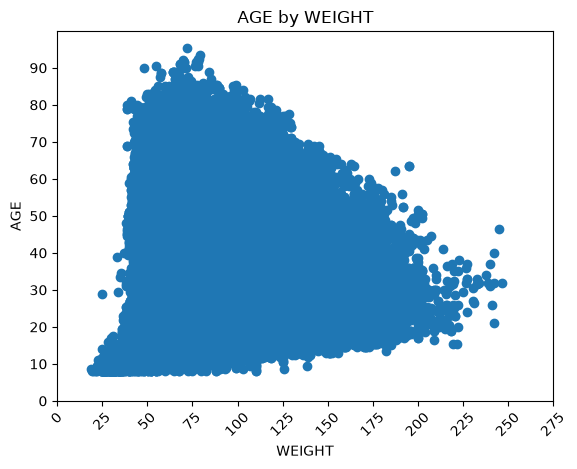

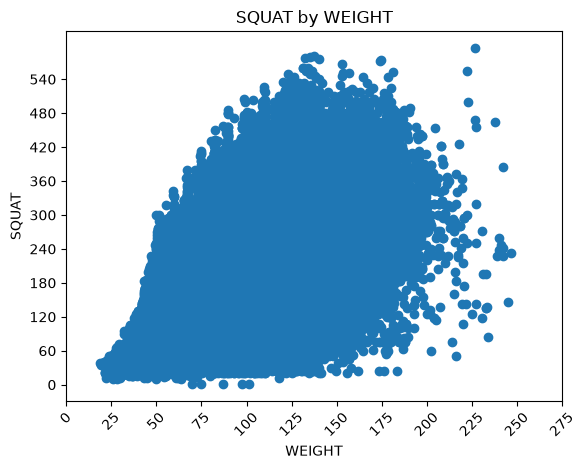

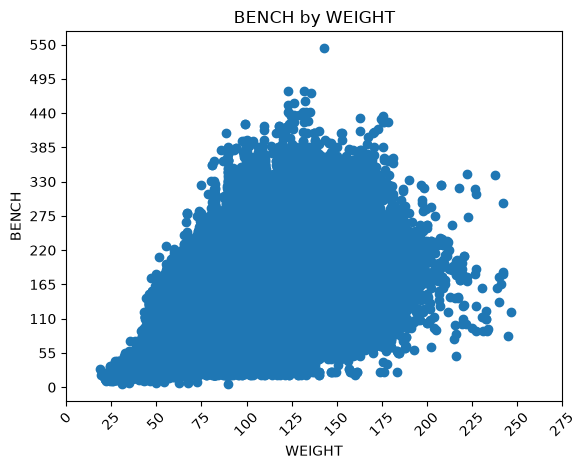

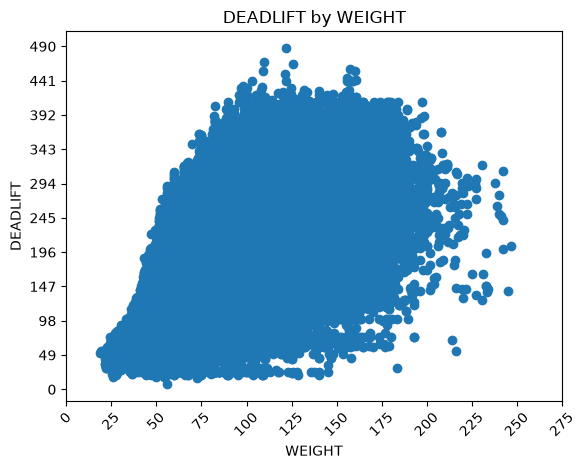

In [246]:
# VISUALIZATION SCATTERPLOT ARRAY BY "WEIGHT"

scatterplot_array(
    dataframe = df,
    independent_feature = "WEIGHT",
    dependent_features = numerical_features
)

#### Attribute: SQUAT

In [247]:
df[(df["SQUAT"] > 550) & (df["DEADLIFT"] < 300)]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
1090197,36.0,226.50,595.00,317.50,295.00,1
1759492,46.0,174.18,571.53,65.77,65.77,1
2301600,39.0,137.44,581.05,118.39,120.66,1


In [251]:
df.sort_values(by="BENCH", ascending=False)[:5]

,AGE,WEIGHT,SQUAT,BENCH,DEADLIFT,IS_MALE
1015289,32.0,142.88,74.84,544.31,65.77,1
1015302,38.0,122.92,510.29,476.27,331.12,1
1176332,33.0,131.65,532.50,475.00,272.50,1
1222123,32.0,135.70,530.00,472.50,342.50,1
1191069,31.0,132.60,577.50,460.00,370.00,1


In [252]:
df.drop(
    [
        1090197,
        1759492,
        2301600,

        1015289
    ], 
    inplace=True
)

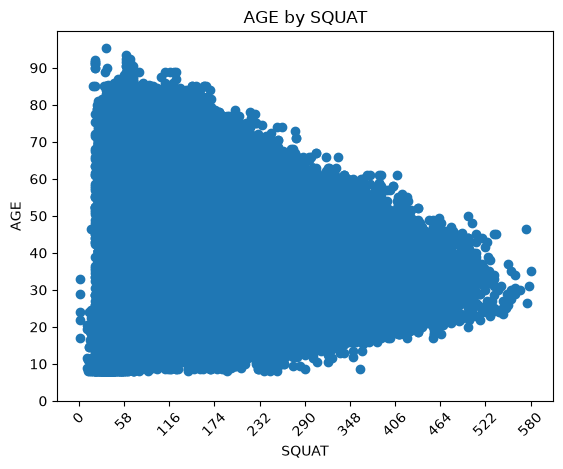

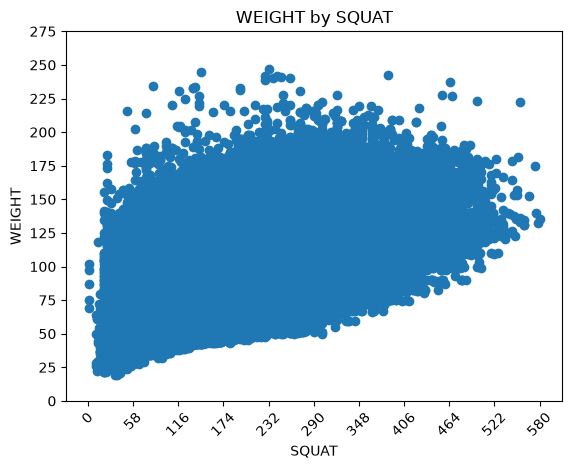

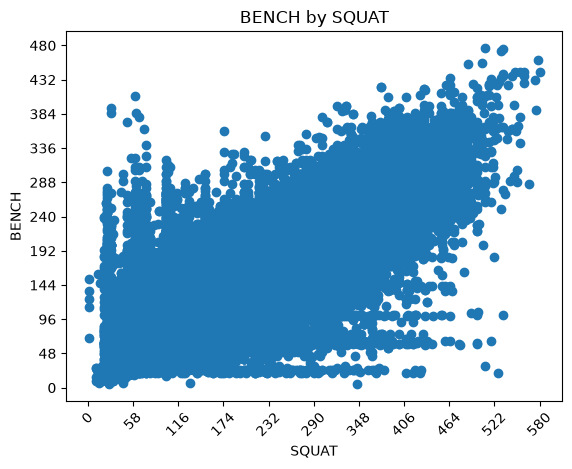

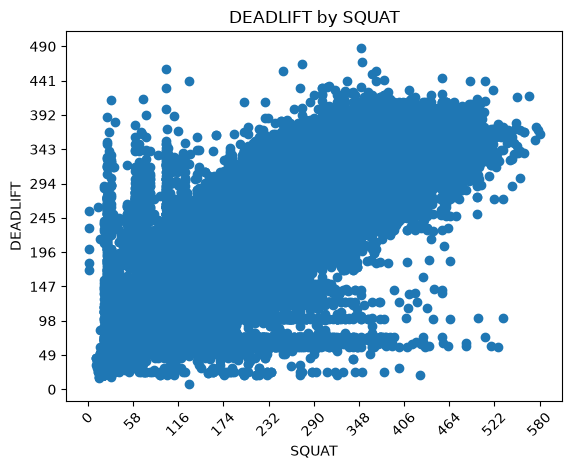

In [253]:
scatterplot_array(
    dataframe = df,
    independent_feature = "SQUAT",
    dependent_features = numerical_features
)

### Attribute: BENCH

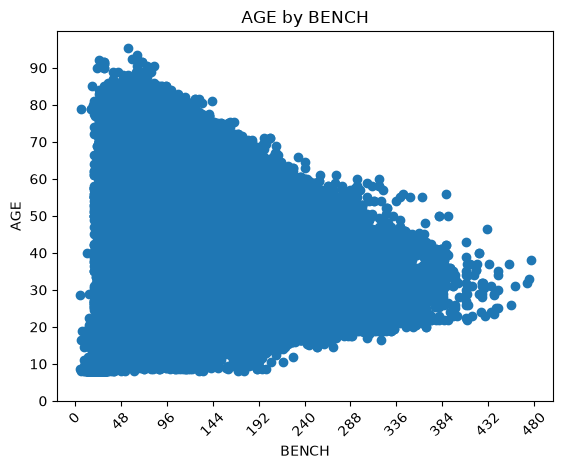

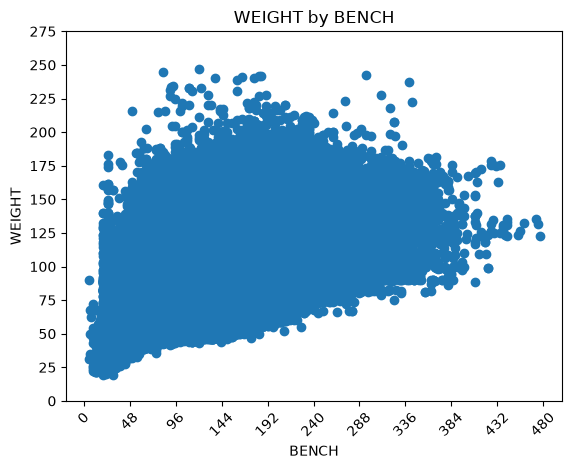

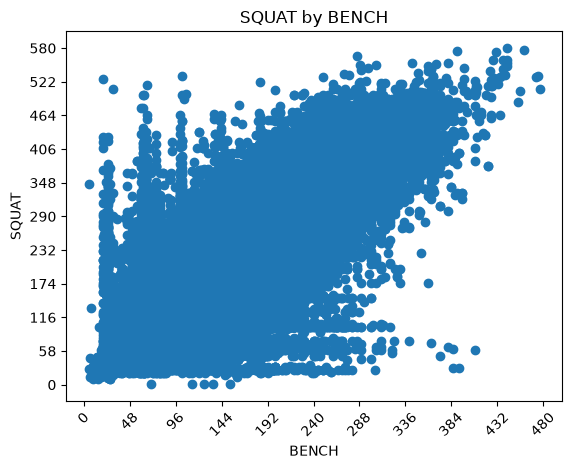

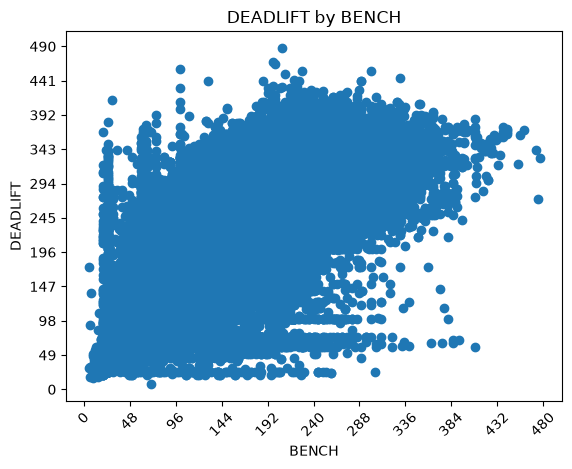

In [254]:
scatterplot_array(
    dataframe = df,
    independent_feature = "BENCH",
    dependent_features = numerical_features
)

No remarkable outliers in BENCH